# Feature Engineering
## Lagos & Abuja Rent Prediction 
## 3MTT Capstone Project
### Objective
Prepare the cleaned dataset for machine learning by:
- Selecting relevant features
- Cleaning categorical variables
- Encoding text features
- Creating new features where necessary
- Preparing the final dataset for model training

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [72]:
df = pd.read_csv("../data/processed/rent_clean_v2.csv")

In [73]:
df.head()

,Title,More Info,Location,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,"White Oak Estate, Ologolo Opp. Agungi, Ologolo...",5000000.0,0,1,0,4.0,4.0,5.0
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,"Hrc Estate Beside Vgc Estate, Vgc Lekki Lagos",5000000.0,0,1,0,4.0,4.0,5.0
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,Osapa London Lekki Lagos,3500000.0,1,0,0,2.0,3.0,3.0
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,Ologolo Lekki Lagos,2700000.0,1,1,0,2.0,3.0,3.0
4,?? Brand New 2 Bedroom Flat For Rent!!! (groun...,2 BEDROOM HOUSE FOR RENT,Mojisola Onikoyi Ikoyi Lagos,5000000.0,1,1,0,2.0,3.0,3.0


In [74]:
df.shape

(97225, 10)

In [75]:
df.dtypes

Title           object
More Info       object
Location        object
Price          float64
Serviced         int64
Newly Built      int64
Furnished        int64
Bedrooms       float64
Bathrooms      float64
Toilets        float64
dtype: object

In [76]:
# Which Columns Should We Use?
df.columns

Index(['Title', 'More Info', 'Location', 'Price', 'Serviced', 'Newly Built',
       'Furnished', 'Bedrooms', 'Bathrooms', 'Toilets'],
      dtype='object')

In [77]:
# Inspect the Location Column
df["Location"].head(20)

0     White Oak Estate, Ologolo Opp. Agungi, Ologolo...
1         Hrc Estate Beside Vgc Estate, Vgc Lekki Lagos
2                              Osapa London Lekki Lagos
3                                   Ologolo Lekki Lagos
4                          Mojisola Onikoyi Ikoyi Lagos
5                                   Chevron Lekki Lagos
6          Banana Island Road Banana Island Ikoyi Lagos
7                        Banana Island Road Ikoyi Lagos
8                                   Chevron Lekki Lagos
9                            Lekki Palm City Ajah Lagos
10        Banana Island Ikoyi Banana Island Ikoyi Lagos
11        Admiralty Way Lekki Lekki Phase 1 Lekki Lagos
12                    Lekki Palm City Estate Ajah Lagos
13                                   Agungi Lekki Lagos
14                                    Ikate Lekki Lagos
15                                  Chevron Lekki Lagos
16                             Osapa London Lekki Lagos
17                                Victoria Islan

In [78]:
df["Location"].nunique()

32291

In [79]:
# See the Most Common Locations
df["Location"].value_counts().head(20)

Location
Lekki Phase 1 Lekki Lagos                                    3165
Ikate Lekki Lagos                                            1269
Osapa London Lekki Lagos                                     1229
Chevron Lekki Lagos                                           990
Banana Island Ikoyi Lagos                                     944
Oniru Victoria Island Lagos                                   882
Ikota Lekki Lagos                                             867
Magodo Gra Phase 1 Ojodu Lagos                                793
Ajao Estate Isolo. Lagos Mainland Ajao Estate Isolo Lagos     730
Ikoyi Lagos                                                   563
Old Ikoyi Ikoyi Lagos                                         555
Lekki Lagos                                                   526
Agungi Lekki Lagos                                            518
Victoria Island Lagos                                         514
Akoka Yaba Lagos                                              471
O

In [80]:
# Check for Inconsistent Location Names
df["Location"].sort_values().unique()[:30]

array([' Abaranje Ikotun Igando Lagos', ' Abijo Ajah Lagos',
       ' Abraham Adesanya Estate Ajah Lagos',
       ' Abule Egba Abule Egba Lagos', ' Abule Egba Lagos',
       ' Abule Ijesha Yaba Lagos', ' Abule Oja Yaba Lagos',
       ' Acme Road Ogba Lagos', ' Ada George Port Harcourt Rivers',
       ' Adekunle Yaba Lagos', ' Adelabu Surulere Lagos',
       ' Adeniran Ogunsanya Surulere Lagos', ' Adeniyi Jones Ikeja Lagos',
       ' Adeola Odeku Victoria Island Lagos', ' Ado Ajah Lagos',
       ' Agege Lagos', ' Agidingbi Ikeja Lagos',
       ' Ago Palace Okota Lagos', ' Agodi Ibadan Oyo',
       ' Agric Ikorodu Lagos', ' Aguda Surulere Lagos',
       ' Aguda(ogba) Ogba Lagos', ' Agungi Lekki Lagos',
       ' Ahmadu Bello Way Victoria Island Lagos',
       ' Airport Road Oshodi Lagos', ' Ajah Lagos',
       ' Ajao Estate Isolo Lagos', ' Ajayi Road Ogba Lagos',
       ' Ajibade Oke Street Ajao Estate Isolo Lagos',
       ' Ajibode Ibadan Oyo'], dtype=object)

In [81]:
# Are All Properties in Lagos or Abuja?
df["Location"].sample(30)

73178                                  ... Life Camp Abuja
76295                                          Ikoyi Lagos
41322     Queens College By Oyediran, Yaba Sabo Yaba Lagos
70238                              Lawanson Surulere Lagos
53753                                Old Ikoyi Ikoyi Lagos
71720                            Lekki Phase 1 Lekki Lagos
28394               Mogana Estate Akala Express Ibadan Oyo
20997                                  Chevron Lekki Lagos
83388    Located Along Dawaki News Engineering Kubwa Abuja
80443                            Omole Phase 1 Ojodu Lagos
56468    Okporo Road Port Harcourt Aba Expressway Port ...
9010                         Even Estate Badore Ajah Lagos
87789    Adeniyi Jones Ikeja Lagos 1.5m Adeniyi Jones I...
89043            Green Field Estate Ago Palace Okota Lagos
86449                                        Gbagada Lagos
36986                            Seaside Badore Ajah Lagos
26222                                     Onike Yaba Lag

In [82]:
# Create a Feature List
features = [
    "Location",
    "Serviced",
    "Newly Built",
    "Furnished",
    "Bedrooms",
    "Bathrooms",
    "Toilets"
]

features

['Location',
 'Serviced',
 'Newly Built',
 'Furnished',
 'Bedrooms',
 'Bathrooms',
 'Toilets']

In [83]:
# Create the Target Variable
target = "Price"

target

'Price'

In [84]:
# Create X and y
X = df[features]

X.head()

,Location,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets
0,"White Oak Estate, Ologolo Opp. Agungi, Ologolo...",0,1,0,4.0,4.0,5.0
1,"Hrc Estate Beside Vgc Estate, Vgc Lekki Lagos",0,1,0,4.0,4.0,5.0
2,Osapa London Lekki Lagos,1,0,0,2.0,3.0,3.0
3,Ologolo Lekki Lagos,1,1,0,2.0,3.0,3.0
4,Mojisola Onikoyi Ikoyi Lagos,1,1,0,2.0,3.0,3.0


In [85]:
y = df[target]

y.head()

0    5000000.0
1    5000000.0
2    3500000.0
3    2700000.0
4    5000000.0
Name: Price, dtype: float64

In [86]:
# Check the Shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (97225, 7)
Shape of y: (97225,)


In [87]:
# Verify There Are No Missing Values
X.isnull().sum()

Location       0
Serviced       0
Newly Built    0
Furnished      0
Bedrooms       0
Bathrooms      0
Toilets        0
dtype: int64

In [88]:
y.isnull().sum()

0

## Selected Features

- Location
- Serviced
- Newly Built
- Furnished
- Bedrooms
- Bathrooms
- Toilets

Target:

- Price

In [89]:
# Inspect the Location Column
df["Location"].head(20)

0     White Oak Estate, Ologolo Opp. Agungi, Ologolo...
1         Hrc Estate Beside Vgc Estate, Vgc Lekki Lagos
2                              Osapa London Lekki Lagos
3                                   Ologolo Lekki Lagos
4                          Mojisola Onikoyi Ikoyi Lagos
5                                   Chevron Lekki Lagos
6          Banana Island Road Banana Island Ikoyi Lagos
7                        Banana Island Road Ikoyi Lagos
8                                   Chevron Lekki Lagos
9                            Lekki Palm City Ajah Lagos
10        Banana Island Ikoyi Banana Island Ikoyi Lagos
11        Admiralty Way Lekki Lekki Phase 1 Lekki Lagos
12                    Lekki Palm City Estate Ajah Lagos
13                                   Agungi Lekki Lagos
14                                    Ikate Lekki Lagos
15                                  Chevron Lekki Lagos
16                             Osapa London Lekki Lagos
17                                Victoria Islan

In [90]:
# How Many Unique Locations?
df["Location"].nunique()

32291

In [91]:
# See the Most Common Locations
df["Location"].value_counts().head(20)

Location
Lekki Phase 1 Lekki Lagos                                    3165
Ikate Lekki Lagos                                            1269
Osapa London Lekki Lagos                                     1229
Chevron Lekki Lagos                                           990
Banana Island Ikoyi Lagos                                     944
Oniru Victoria Island Lagos                                   882
Ikota Lekki Lagos                                             867
Magodo Gra Phase 1 Ojodu Lagos                                793
Ajao Estate Isolo. Lagos Mainland Ajao Estate Isolo Lagos     730
Ikoyi Lagos                                                   563
Old Ikoyi Ikoyi Lagos                                         555
Lekki Lagos                                                   526
Agungi Lekki Lagos                                            518
Victoria Island Lagos                                         514
Akoka Yaba Lagos                                              471
O

In [22]:
# Inspect Every Unique Location
locations = sorted(df["Location"].unique())

locations[:50]

[' Abaranje Ikotun Igando Lagos',
 ' Abijo Ajah Lagos',
 ' Abraham Adesanya Estate Ajah Lagos',
 ' Abule Egba Abule Egba Lagos',
 ' Abule Egba Lagos',
 ' Abule Ijesha Yaba Lagos',
 ' Abule Oja Yaba Lagos',
 ' Acme Road Ogba Lagos',
 ' Ada George Port Harcourt Rivers',
 ' Adekunle Yaba Lagos',
 ' Adelabu Surulere Lagos',
 ' Adeniran Ogunsanya Surulere Lagos',
 ' Adeniyi Jones Ikeja Lagos',
 ' Adeola Odeku Victoria Island Lagos',
 ' Ado Ajah Lagos',
 ' Agege Lagos',
 ' Agidingbi Ikeja Lagos',
 ' Ago Palace Okota Lagos',
 ' Agodi Ibadan Oyo',
 ' Agric Ikorodu Lagos',
 ' Aguda Surulere Lagos',
 ' Aguda(ogba) Ogba Lagos',
 ' Agungi Lekki Lagos',
 ' Ahmadu Bello Way Victoria Island Lagos',
 ' Airport Road Oshodi Lagos',
 ' Ajah Lagos',
 ' Ajao Estate Isolo Lagos',
 ' Ajayi Road Ogba Lagos',
 ' Ajibade Oke Street Ajao Estate Isolo Lagos',
 ' Ajibode Ibadan Oyo',
 ' Ajiwe Ajah Lagos',
 ' Akala Express Ibadan Oyo',
 ' Akamsi Alapere Kosofe Ikosi Lagos',
 ' Akobo Ibadan Oyo',
 ' Akoka Yaba Lagos

In [92]:
# How Many Missing Locations?
df["Location"].isnull().sum()

0

In [93]:
# Are There Leading or Trailing Spaces?
df["Location"].str.startswith(" ").sum()

2264

In [94]:
df["Location"].str.endswith(" ").sum()

0

In [95]:
# Standardize the Text
df["Location"] = df["Location"].str.strip()

In [96]:
df["Location"] = df["Location"].str.title()

In [97]:
# Checking Again
df["Location"].nunique()

31999

In [98]:
# Do We Have Only Lagos and Abuja?
df["Location"].sample(30, random_state=42)

16183                         Mobile Road Ilaje Ajah Lagos
13203                       Oluwaga Ipaja Road Ipaja Lagos
59290                                   Ring Rd Ibadan Oyo
44725    Promiseland Off Elebu Oluyole Extension Akala ...
25324                            Lekki Phase 1 Lekki Lagos
35154    Cathedral Court Ikota Villa Estate Ikota Lekki...
63943                                    .... Wuse 2 Abuja
27001                            Banana Island Ikoyi Lagos
6299                                    Baruwa Ipaja Lagos
67403                                    Badore Ajah Lagos
74695                                    Ojota Ojota Lagos
64095                          Eliozu Port Harcourt Rivers
9209                           Ifako Gbagada Gbagada Lagos
43608                         Ulo , Awai , Dla Asaba Delta
17096    Sanusi Fafunwa Street Victoria Island Extensio...
29468                   Amikanle Alagbado Abule Egba Lagos
81429                       Baruwa,Ipaja Ipaja Ipaja Lag

In [99]:
# Save Our Progress
df.to_csv("../data/processed/rent_clean_v3.csv", index=False)

In [100]:
# How Many Locations Do We Have?
df["Location"].nunique()

31999

In [101]:
# Perform One-Hot Encoding
location_counts = df["Location"].value_counts()

common_locations = location_counts[location_counts >= 50].index

df["Location"] = df["Location"].where(
    df["Location"].isin(common_locations),
    "Other"
)

In [102]:
# Check the reduction
df["Location"].nunique()

212

In [103]:
# Perform One-Hot Encoding
Location_encoded = pd.get_dummies(
    df["Location"],
    prefix="Location",
    dtype=int
)

In [104]:
# Inspect the Encoded Data
Location_encoded.head()

,Location_... Lekki Phase 1 Lekki Lagos,Location_Abijo Ajah Lagos,Location_Abraham Adesanya Estate Ajah Lagos,Location_Abule Egba Abule Egba Lagos,Location_Abule Egba Lagos,Location_Abule Ijesha Yaba Lagos,Location_Abule Oja Yaba Lagos,Location_Adekunle Yaba Lagos,Location_Adelabu Surulere Lagos,Location_Adeniran Ogunsanya Surulere Lagos,...,Location_Unity Estate Egbeda Alimosho Lagos,Location_Utako Abuja,Location_Vgc Lekki Lagos,Location_Victoria Island Extension Victoria Island Lagos,Location_Victoria Island Lagos,Location_Wuse 2 Abuja,Location_Wuse2 Wuse 2 Abuja,Location_Wuye Abuja,Location_Wuye Wuye Abuja,Location_Yaba Lagos
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [105]:
# Remove the Original Location Column
#We don't need the text version anymore
df = df.drop("Location", axis=1)

In [106]:
# Combine the Encoded Columns
df = pd.concat([df, Location_encoded], axis=1)

In [107]:
# Verify the Result
df.head()

,Title,More Info,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets,Location_... Lekki Phase 1 Lekki Lagos,...,Location_Unity Estate Egbeda Alimosho Lagos,Location_Utako Abuja,Location_Vgc Lekki Lagos,Location_Victoria Island Extension Victoria Island Lagos,Location_Victoria Island Lagos,Location_Wuse 2 Abuja,Location_Wuse2 Wuse 2 Abuja,Location_Wuye Abuja,Location_Wuye Wuye Abuja,Location_Yaba Lagos
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,5000000.0,0,1,0,4.0,4.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,5000000.0,0,1,0,4.0,4.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,3500000.0,1,0,0,2.0,3.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,2700000.0,1,1,0,2.0,3.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0
4,?? Brand New 2 Bedroom Flat For Rent!!! (groun...,2 BEDROOM HOUSE FOR RENT,5000000.0,1,1,0,2.0,3.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0


In [108]:
# Check the Shape
df.shape

(97225, 221)

In [109]:
# Save the Machine Learning Dataset
df.to_csv("../data/processed/model_ready_data.csv", index=False)

In [110]:
# Load the Model-Ready Dataset
df = pd.read_csv("../data/processed/model_ready_data.csv")

In [111]:
# verifying
df.head()

,Title,More Info,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets,Location_... Lekki Phase 1 Lekki Lagos,...,Location_Unity Estate Egbeda Alimosho Lagos,Location_Utako Abuja,Location_Vgc Lekki Lagos,Location_Victoria Island Extension Victoria Island Lagos,Location_Victoria Island Lagos,Location_Wuse 2 Abuja,Location_Wuse2 Wuse 2 Abuja,Location_Wuye Abuja,Location_Wuye Wuye Abuja,Location_Yaba Lagos
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,5000000.0,0,1,0,4.0,4.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,5000000.0,0,1,0,4.0,4.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,3500000.0,1,0,0,2.0,3.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,2700000.0,1,1,0,2.0,3.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0
4,?? Brand New 2 Bedroom Flat For Rent!!! (groun...,2 BEDROOM HOUSE FOR RENT,5000000.0,1,1,0,2.0,3.0,3.0,0,...,0,0,0,0,0,0,0,0,0,0


In [112]:
#  Check the Columns
df.columns

Index(['Title', 'More Info', 'Price', 'Serviced', 'Newly Built', 'Furnished',
       'Bedrooms', 'Bathrooms', 'Toilets',
       'Location_... Lekki Phase 1 Lekki Lagos',
       ...
       'Location_Unity Estate Egbeda Alimosho Lagos', 'Location_Utako Abuja',
       'Location_Vgc Lekki Lagos',
       'Location_Victoria Island Extension Victoria Island Lagos',
       'Location_Victoria Island Lagos', 'Location_Wuse 2 Abuja',
       'Location_Wuse2 Wuse 2 Abuja', 'Location_Wuye Abuja',
       'Location_Wuye Wuye Abuja', 'Location_Yaba Lagos'],
      dtype='object', length=221)

In [113]:
# Separate Target from Features
# Create y (Target)
y = df["Price"]

In [114]:
y.head()

0    5000000.0
1    5000000.0
2    3500000.0
3    2700000.0
4    5000000.0
Name: Price, dtype: float64

In [115]:
# Create X (Features)
X = df.drop("Price", axis=1)

In [116]:
X.head()

,Title,More Info,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets,Location_... Lekki Phase 1 Lekki Lagos,Location_Abijo Ajah Lagos,...,Location_Unity Estate Egbeda Alimosho Lagos,Location_Utako Abuja,Location_Vgc Lekki Lagos,Location_Victoria Island Extension Victoria Island Lagos,Location_Victoria Island Lagos,Location_Wuse 2 Abuja,Location_Wuse2 Wuse 2 Abuja,Location_Wuye Abuja,Location_Wuye Wuye Abuja,Location_Yaba Lagos
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,0,1,0,4.0,4.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,0,1,0,4.0,4.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,1,0,0,2.0,3.0,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,1,1,0,2.0,3.0,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,?? Brand New 2 Bedroom Flat For Rent!!! (groun...,2 BEDROOM HOUSE FOR RENT,1,1,0,2.0,3.0,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [117]:
# Check Shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (97225, 220)
y shape: (97225,)


In [118]:
# Check Data Types
X.dtypes.value_counts()

int64      215
float64      3
object       2
Name: count, dtype: int64

In [119]:
# Check Missing Values
X.isnull().sum().sum()

1

In [120]:
y.isnull().sum()

0

In [121]:
# Check the Target Distribution Again
y.describe()

count    9.722500e+04
mean     4.263248e+07
std      6.757220e+09
min      0.000000e+00
25%      6.000000e+05
50%      1.300000e+06
75%      3.500000e+06
max      1.700000e+12
Name: Price, dtype: float64

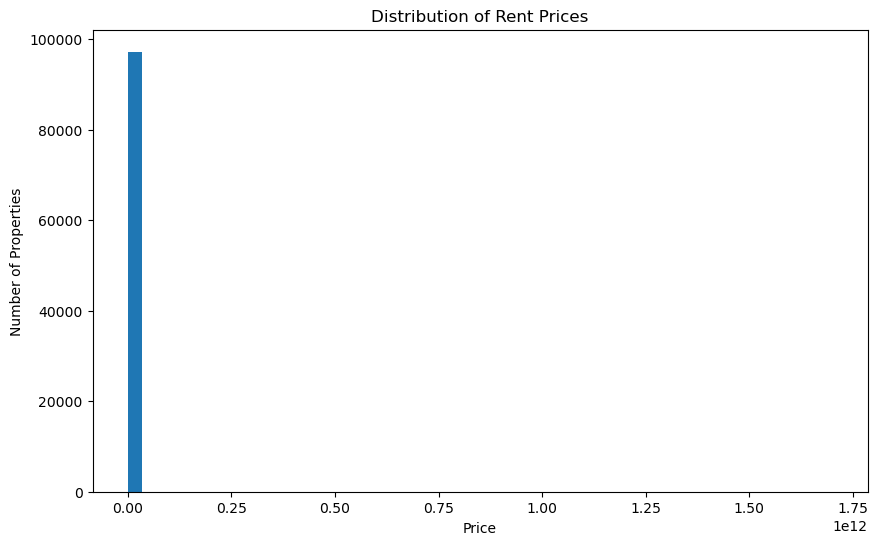

In [122]:
# Investigating the Target Variable
plt.figure(figsize=(10,6))

plt.hist(y, bins=50)

plt.title("Distribution of Rent Prices")
plt.xlabel("Price")
plt.ylabel("Number of Properties")

plt.show()

In [123]:
# Create a Temporary Clean Target
y[y < 20_000_000].describe()

count    9.480100e+04
mean     2.454739e+06
std      3.074386e+06
min      0.000000e+00
25%      6.000000e+05
50%      1.200000e+06
75%      3.000000e+06
max      1.955000e+07
Name: Price, dtype: float64

In [124]:
y.describe()

count    9.722500e+04
mean     4.263248e+07
std      6.757220e+09
min      0.000000e+00
25%      6.000000e+05
50%      1.300000e+06
75%      3.500000e+06
max      1.700000e+12
Name: Price, dtype: float64

In [126]:
# Save the Feature-Engineered Dataset
X.to_csv("../data/processed/X_features.csv", index=False)

y.to_csv("../data/processed/y_target.csv", index=False)

In [127]:
# Calculate Q1 and Q3
y.describe()

count    9.722500e+04
mean     4.263248e+07
std      6.757220e+09
min      0.000000e+00
25%      6.000000e+05
50%      1.300000e+06
75%      3.500000e+06
max      1.700000e+12
Name: Price, dtype: float64

In [128]:
# Calculate the IQR
Q1 = y.quantile(0.25)

Q3 = y.quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 600000.0
Q3: 3500000.0
IQR: 2900000.0


In [129]:
# Calculate the Upper Limit
upper_limit = Q3 + 1.5 * IQR

lower_limit = Q1 - 1.5 * IQR


print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: -3750000.0
Upper limit: 7850000.0


In [130]:
# Count How Many Outliers Exist
outliers = y[
    (y < lower_limit) |
    (y > upper_limit)
]

print("Number of outliers:", len(outliers))


Number of outliers: 9057


In [132]:
# Create a Filter
mask = (
    (y >= lower_limit) &
    (y <= upper_limit)
)

In [133]:
# Apply the Filter
X_clean = X[mask]

y_clean = y[mask]

In [134]:
print("Original X:", X.shape)
print("Clean X:", X_clean.shape)

print("Original y:", y.shape)
print("Clean y:", y_clean.shape)

Original X: (97225, 220)
Clean X: (88168, 220)
Original y: (97225,)
Clean y: (88168,)


In [135]:
# Check the New Price Distribution
y_clean.describe()

count    8.816800e+04
mean     1.774656e+06
std      1.696630e+06
min      0.000000e+00
25%      5.500000e+05
50%      1.050000e+06
75%      2.500000e+06
max      7.700000e+06
Name: Price, dtype: float64

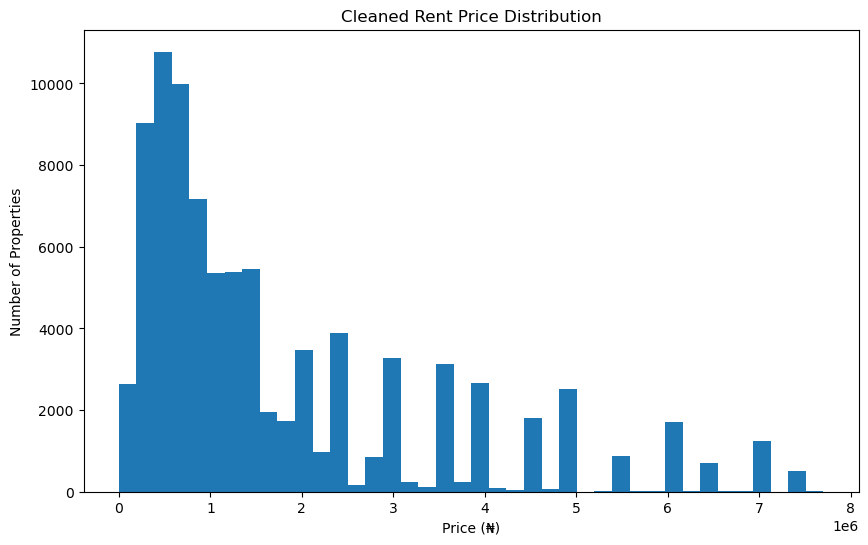

In [136]:
# Visualize Again
plt.figure(figsize=(10,6))

plt.hist(y_clean, bins=40)

plt.title("Cleaned Rent Price Distribution")

plt.xlabel("Price (₦)")

plt.ylabel("Number of Properties")

plt.show()

In [138]:
# Save the Final Modeling Data
X_clean.to_csv(
    "../data/processed/final_features.csv",
    index=False
)

In [139]:
y_clean.to_csv(
    "../data/processed/final_target.csv",
    index=False
)

In [140]:
# Import Train-Test Split
from sklearn.model_selection import train_test_split

In [141]:
# Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

In [142]:
# Check the Split
print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (70534, 220)
X_test: (17634, 220)
y_train: (70534,)
y_test: (17634,)
